The Mean Absolute Error (MAE) value is (MAE): 0.009572193827899724
The Mean Squared Error (MSE) value is: 0.00016127421048530536
Root Mean Squared Error (RMSE): 0.012699378350348704
R-squared (R²) Score: 0.8810985372539569


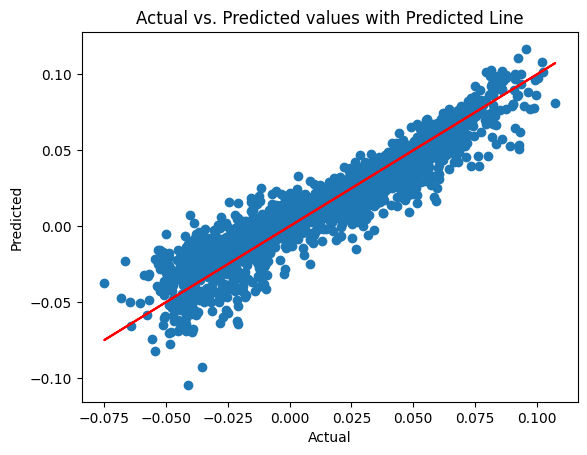

In [ ]:
import pandas as pd # Import the pandas library which is used for data manipulation and for preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV # Imports the training and testing split sub-libraries from sklearn to use for neural networking as well as the
from sklearn.linear_model import LinearRegression # Imports the linear regression model from the sklearn library
from sklearn.preprocessing import StandardScaler, PolynomialFeatures # Imports the StandardScaler and PolynomialFeatures from the preprocessing sub-library of sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Imports the libraries needed for analysis of the performance of the model
import matplotlib.pyplot as graph # Imports the library needed for producing MATLAB-like plots for Python

def setup(): # Defines the setup function that is needed to start building the model
    df = pd.read_csv("Data_for_UCI_named.csv") # Reads the CSV file of grid stability to be processed by the machine learning model
    X = df.iloc[:, 0:12] # Sets columns 0-12 as the features (X)
    y = df.iloc[:, 12] # Sets the last column as the label (y)

    Training_X, Testing_X, Training_Y, Testing_Y = train_test_split(X, y, test_size=0.2, random_state=42) # Splits the data so that 80% will be used for training and 20% will be used for testing

    scaler = StandardScaler() # Initialize the StandardScaler function

    # Fit and transform the training data
    Training_X_scaled = scaler.fit_transform(Training_X)
    Testing_X_scaled = scaler.transform(Testing_X)

    # Introduce the Polynomial Features that will be used to make the model more complex
    PF = PolynomialFeatures(degree=2)
    Training_X_PF = PF.fit_transform(Training_X_scaled)
    Testing_X_PF = PF.transform(Testing_X_scaled)

    return Training_X_PF, Testing_X_PF, Training_Y, Testing_Y # Retuns the values of the 4 variables

def main(): # Defines the main function that is needed to start building the model
    Training_X_PF, Testing_X_PF, Training_Y, Testing_Y = setup()

    LR = LinearRegression() # Initialize the linear regression model function

    # Set up hyperparameter grid for the GSCV and in this case the TRUE/FALSE indicates that it will try both TRUE and FALSE values for the fit_intercept to determine best performance of the system
    param_grid = {
        'fit_intercept': [True, False],
    }

    # Model setup
    GSCV = GridSearchCV(LR, param_grid, cv=5, scoring='neg_mean_squared_error') # Initialize GridSearchCV
    GSCV.fit(Training_X_PF, Training_Y) # Fit the grid search to the scaled training data with Polynomial features
    best_model = GSCV.best_estimator_ # Gets the best model from the GSCV
    Predicted_Y = best_model.predict(Testing_X_PF) # Make predictions on the scaled testing data with Polynomial features using the best model

    # Outputting the statistical values that can be used for analysis of the performance of the system
    mae = mean_absolute_error(Testing_Y, Predicted_Y) # Calculates the Mean Absolute Error (MAE)
    print(f'The Mean Absolute Error (MAE) value is (MAE): {mae}') # Prints the Mean Absolute Error (MAE)
    mse = mean_squared_error(Testing_Y, Predicted_Y) # Calculates the Mean Squared Error (MSE)
    print(f'The Mean Squared Error (MSE) value is: {mse}') # Prints the Mean Squared Error (MSE)
    rmse = mean_squared_error(Testing_Y, Predicted_Y, squared=False) # Calculates the Root Mean Squared Error (RMSE)
    print(f'Root Mean Squared Error (RMSE): {rmse}') # Prints the Root Mean Squared Error (RMSE)
    r2 = r2_score(Testing_Y, Predicted_Y) # Calculate the R-squared (R²) Score of the dataset
    print(f'R-squared (R²) Score: {r2}') # Prints the R-squared (R²) Score of the dataset

    # Outputting the graph
    graph.scatter(Testing_Y, Predicted_Y, label='Actual vs. Predicted') # Plot the graph of the results to show how the values for testing compare against the predicted value
    graph.plot(Testing_Y, Testing_Y, color='red', label='Predicted = Actual') # Plot a linear line to show where predicted values equal actual values
    graph.xlabel('Actual') # X-axis label for actual values
    graph.ylabel('Predicted') # Y-axis label for predicted values
    graph.title('Actual vs. Predicted values with Predicted Line') # Title of the graph is displayed at the top
    graph.legend() # Helps to clarify the different data on the graph
    graph.show() # Outputs the plot and in this case it will be below the statistical outputs

if __name__ == "__main__":
    main()
